In [3]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 

from utils import *

Calculate persistent entropy transform of a signal/function

PET shape: (64,)
First values: tf.Tensor([-0. -0. -0. -0. -0.], shape=(5,), dtype=float32)


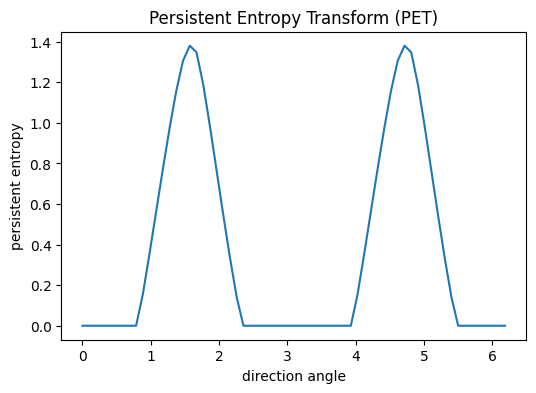

In [4]:
domain =[-10,10]
function=np.sin
n_points = 1000
x_train, y_train = generate_training_data(function, (domain[0], domain[1]), n_points)
x_train = tf.constant(x_train,dtype=tf.float32)
y_train = tf.constant(y_train,dtype=tf.float32)

stbase = gd.SimplexTree()
for i in range(n_points-1):
    stbase.insert([i,i+1], -1e10)
layer = LowerStarLayer(simplextree=stbase)

dgmsRef = layer.call(y_train)
dgmRef = dgmsRef[0][0]
PERef=persistent_entropy(dgmRef)

PET_values, angles = persistent_entropy_transform(
    x_train,
    y_train,
    layer,
    num_directions=64
)

print("PET shape:", PET_values.shape)
print("First values:", PET_values[:5])


plt.figure(figsize=(6,4))
plt.plot(angles, PET_values.numpy())
plt.xlabel("direction angle")
plt.ylabel("persistent entropy")
plt.title("Persistent Entropy Transform (PET)")
plt.show()

Display the PET values, 1 for each direction

In [5]:
PET_values

<tf.Tensor: shape=(64,), dtype=float32, numpy=
array([-0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        ,  0.15379816,
        0.35478458,  0.5648196 ,  0.7744694 ,  0.9761119 ,  1.1595925 ,
        1.3070611 ,  1.3805673 ,  1.3483145 ,  1.1900604 ,  0.9845997 ,
        0.7647494 ,  0.54476887,  0.33326125,  0.14040907, -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        ,  0.15379816,  0.35478458,  0.5648196 ,  0.7744694 ,
        0.9761119 ,  1.1595925 ,  1.3070611 ,  1.3805673 ,  1.3483145 ,
        1.1900604 ,  0.9845997 ,  0.7647494 ,  0.54476887,  0.33326125,
        0.14040907, -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        ], dtype=float32)>

Some experiments: 1) Sensibilidad direccional

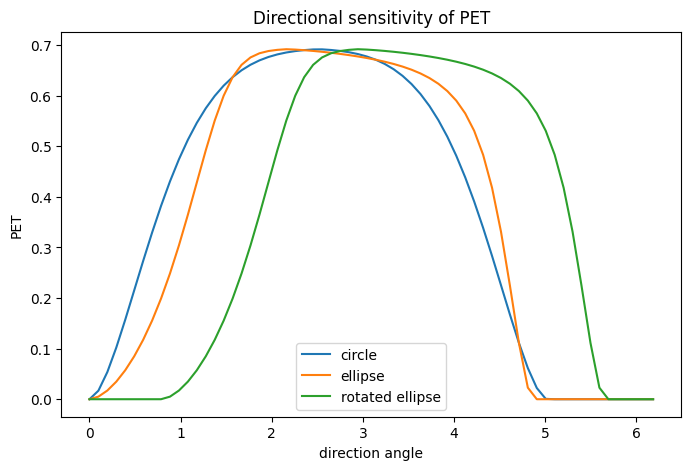

In [7]:

# ---------- SHAPE GENERATORS ----------

def generate_circle(n_points=500, radius=1.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = radius * np.cos(t)
    y = radius * np.sin(t)
    return x, y


def generate_ellipse(n_points=500, a=2.0, b=1.0, rotation=0.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = a * np.cos(t)
    y = b * np.sin(t)

    R = np.array([
        [np.cos(rotation), -np.sin(rotation)],
        [np.sin(rotation),  np.cos(rotation)]
    ])

    pts = R @ np.vstack([x, y])
    return pts[0], pts[1]


def generate_noisy_shape(x, y, sigma):
    noise_x = np.random.normal(0, sigma, len(x))
    noise_y = np.random.normal(0, sigma, len(y))
    return x + noise_x, y + noise_y

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles

def experiment_directional_sensitivity(layer):

    shapes = {
        "circle": generate_circle(),
        "ellipse": generate_ellipse(a=2, b=1),
        "rotated ellipse": generate_ellipse(a=2, b=1, rotation=np.pi/4)
    }

    plt.figure(figsize=(8,5))

    for name, (x, y) in shapes.items():
        pet, angles = compute_pet_from_shape(x, y, layer)
        plt.plot(angles, pet, label=name)

    plt.legend()
    plt.xlabel("direction angle")
    plt.ylabel("PET")
    plt.title("Directional sensitivity of PET")
    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

# Run all experiments
experiment_directional_sensitivity(layer)

2) Experimento 2: Noise robustness


=== Experiment 2: Noise robustness ===
sigma=0.00 -> distance=0.0000
sigma=0.06 -> distance=28.9391
sigma=0.11 -> distance=32.2176
sigma=0.17 -> distance=33.1032
sigma=0.22 -> distance=33.5582
sigma=0.28 -> distance=33.7969
sigma=0.33 -> distance=33.5235
sigma=0.39 -> distance=33.4155
sigma=0.44 -> distance=34.1829
sigma=0.50 -> distance=33.8046


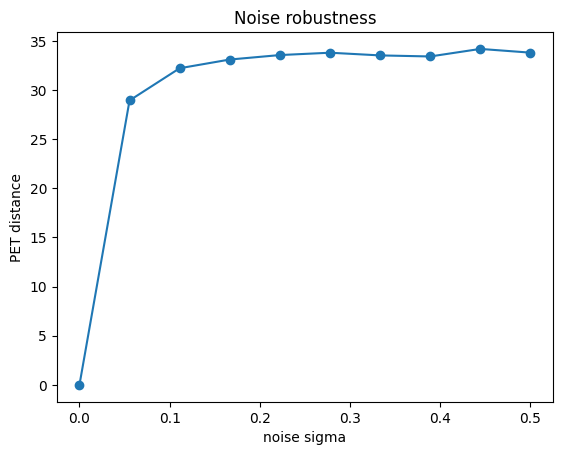

In [8]:
def experiment_noise_stability(layer):

    print("\n=== Experiment 2: Noise robustness ===")

    x,y = generate_ellipse(a=2,b=1)
    pet_clean,_ = compute_pet_from_shape(x,y,layer)

    sigmas = np.linspace(0,0.5,10)
    distances = []

    for sigma in sigmas:
        xn,yn = generate_noisy_shape(x,y,sigma)
        pet_noisy,_ = compute_pet_from_shape(xn,yn,layer)

        dist = np.linalg.norm(pet_clean - pet_noisy)
        distances.append(dist)

        print(f"sigma={sigma:.2f} -> distance={dist:.4f}")

    plt.figure()
    plt.plot(sigmas, distances, marker="o")
    plt.xlabel("noise sigma")
    plt.ylabel("PET distance")
    plt.title("Noise robustness")
    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_noise_stability(layer)

Experiment 3: Clasificación

In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def build_dataset(layer, n_samples=20):

    X=[]
    y_labels=[]

    for _ in range(n_samples):
        x,y = generate_circle()
        pet,_ = compute_pet_from_shape(x,y,layer)
        X.append(pet)
        y_labels.append(0)

    for _ in range(n_samples):
        x,y = generate_ellipse(a=2,b=1)
        pet,_ = compute_pet_from_shape(x,y,layer)
        X.append(pet)
        y_labels.append(1)

    return np.array(X), np.array(y_labels)


def experiment_classification(layer):

    print("\n=== Experiment 3: Classification ===")

    X,y = build_dataset(layer)

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.3,random_state=0
    )

    clf = SVC(kernel="linear")
    clf.fit(X_train,y_train)

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test,preds)

    print("Classification accuracy:",acc)

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_classification(layer)


=== Experiment 3: Classification ===
Classification accuracy: 1.0


Experiment 4: Convergencia por direcciones

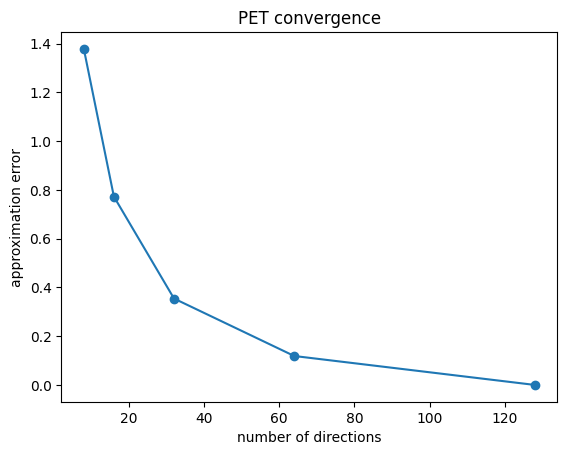

In [ ]:
def experiment_direction_sampling(layer):

    x, y = generate_ellipse(a=2, b=1)

    dirs = [8,16,32,64,128]
    reference,_ = compute_pet_from_shape(x,y,layer,128)

    errors = []

    for d in dirs:
        pet,_ = compute_pet_from_shape(x,y,layer,d)
        interp = np.interp(
            np.linspace(0,1,len(reference)),
            np.linspace(0,1,len(pet)),
            pet
        )

        err = np.linalg.norm(reference - interp)
        errors.append(err)

    plt.figure()
    plt.plot(dirs, errors, marker="o")
    plt.xlabel("number of directions")
    plt.ylabel("approximation error")
    plt.title("PET convergence")
    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_direction_sampling(layer)

Experiment 5: Coste computacional

In [10]:
import time

def experiment_runtime(layer):

    x, y = generate_ellipse()

    for dirs in [8,16,32,64]:
        start = time.time()
        compute_pet_from_shape(x,y,layer,dirs)
        elapsed = time.time() - start

        print(f"Directions={dirs}, time={elapsed:.3f}s")

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_runtime(layer)

Directions=8, time=0.096s
Directions=16, time=0.177s
Directions=32, time=0.330s
Directions=64, time=0.601s
